# Dataset Inspector & Exploratory Data Analysis (EDA) Notebook

This notebook imports `engineered_splits.npz`, converts it to a Pandas DataFrame, and runs visualizations for posture, locomotion, time-series, and data quality features using a consistent color theme.

In [42]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Consistent class color mapping: red for falling, blue for running, grey for others
colors = {"others": "grey", "running": "blue", "falling": "red"}

# Ensure project root is in python path to import backend services
project_root = Path('.').resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from backend.app.services.video_features import feature_columns

## 1. Load Combined NPZ Splits Data

In [43]:
dataset_name = 'test'
train_path = project_root / f'{dataset_name}_split.npz'
data = dict(np.load(train_path, allow_pickle=True))

for key, array in data.items():
    print(f"{key:<16} : shape={array.shape}, dtype={array.dtype}")

X                : shape=(631, 141), dtype=float32
y                : shape=(631,), dtype=int64
video_ids        : shape=(631,), dtype=object


## 2. Construct Pandas DataFrame

In [44]:
# Retrieve the 143 original columns, excluding 'track_gap_count' and 'valid_frame_ratio' which were deleted
exclude_features = {'track_gap_count', 'valid_frame_ratio'}
columns = [col for col in feature_columns() if col not in exclude_features]

# Create training DataFrame using only train_split.npz data
df = pd.DataFrame(data['X'], columns=columns)
df.insert(0, 'video_id', data['video_ids'])
df['label'] = data['y']

# Behavior label name mapping
label_map = {0: 'others', 1: 'running', 2: 'falling'}
df['behavior'] = df['label'].map(label_map)

print(f"DataFrame dimensions: {df.shape} (rows, columns)")
df.head()

DataFrame dimensions: (631, 144) (rows, columns)


,video_id,torso_angle_mean,torso_angle_std,head_hip_compression_mean,hip_ankle_vertical_diff_mean,skeleton_spread_ratio_mean,skeleton_spread_ratio_max,ground_speed_mean,ground_speed_max,scale_speed_mean,...,final_lying_score,final_1s_body_speed_mean,final_1s_joint_motion_mean,final_1s_joint_motion_std,avg_keypoint_confidence,missing_ankle_ratio,missing_hip_ratio,skeleton_jump_score,label,behavior
0,fall_video_225,80.533432,4.731608,0.366810,0.302512,0.377779,0.463601,0.077257,0.229410,0.058491,...,0.333333,0.138795,0.008065,0.002116,0.864901,0.0,0.0,0.012614,0,others
1,fall_video_225,78.522575,5.807795,0.377318,0.297841,0.385016,0.446179,0.072288,0.273644,0.052344,...,0.349296,0.108551,0.004917,0.003230,0.868185,0.0,0.0,0.012614,0,others
2,fall_video_225,77.112549,6.391518,0.383511,0.295720,0.392063,0.443562,0.070296,0.273644,0.046505,...,0.356702,0.023028,0.001652,0.000933,0.868732,0.0,0.0,0.011601,0,others
3,fall_video_225,74.245987,5.083480,0.390836,0.288868,0.410506,0.515531,0.074747,0.273644,0.048440,...,0.358318,0.027564,0.002140,0.001558,0.869999,0.0,0.0,0.011460,0,others
4,fall_video_225,72.953506,2.894352,0.389229,0.282802,0.431860,0.515531,0.084414,0.273644,0.049123,...,0.340592,0.135037,0.006437,0.004089,0.865558,0.0,0.0,0.014595,0,others


## 3. Class Balance Check

behavior
others     0.727417
falling    0.196513
running    0.076070
Name: count, dtype: float64


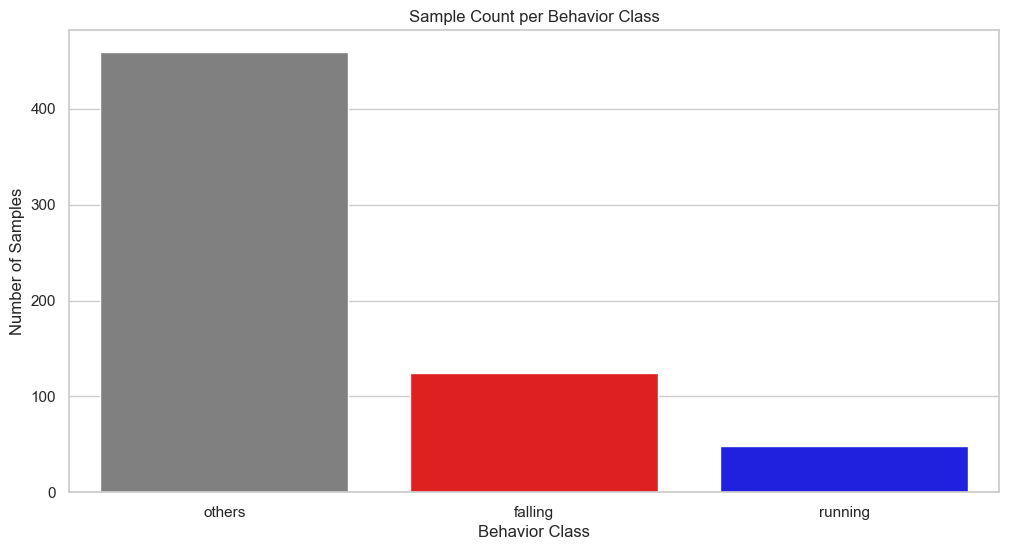

In [45]:
# count samples per behavior
class_counts = df['behavior'].value_counts()
print(class_counts / class_counts.sum())

sns.barplot(hue=class_counts.index, legend=False, x = class_counts.index, y=class_counts.values, palette=[colors[label] for label in class_counts.index])
plt.title("Sample Count per Behavior Class")
plt.xlabel("Behavior Class")
plt.ylabel("Number of Samples")
plt.show()

The number of samples for classes are imbalanced. This issue needs to be solved.

Balanced Train Class Count:
behavior
others     0.727417
falling    0.196513
running    0.076070
Name: count, dtype: float64


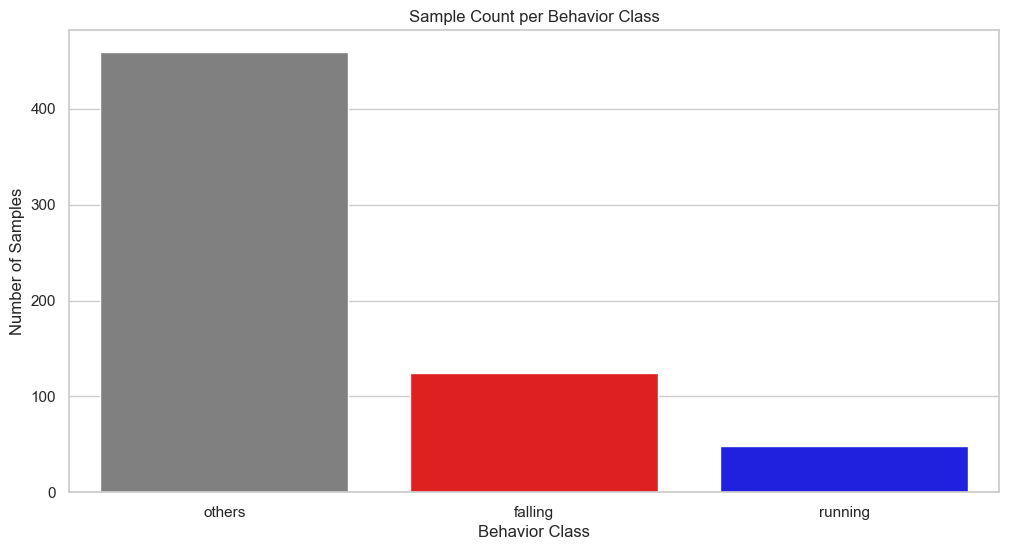

In [46]:
if dataset_name == 'train':
  # 1. Separate training DataFrame by class
  df_others = df[df['label'] == 0]
  df_running = df[df['label'] == 1]
  df_falling = df[df['label'] == 2]

  # Define target size per class (undersample others, oversample running & falling)
  target_size = 1200

  # 2. Resample classes
  df_others_resampled = df_others.sample(n=target_size, random_state=42, replace=False)
  df_running_resampled = df_running.sample(n=target_size, random_state=42, replace=True)
  df_falling_resampled = df_falling.sample(n=target_size, random_state=42, replace=True)

  # 3. Overwrite df with concatenated and shuffled balanced training dataset
  df = pd.concat([df_others_resampled, df_running_resampled, df_falling_resampled])
  df = df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("Balanced Train Class Count:")
class_counts = df['behavior'].value_counts()
print(class_counts / class_counts.sum())

# 4. Plot the balanced class distribution
sns.barplot(hue=class_counts.index, legend=False, x = class_counts.index, y=class_counts.values, palette=[colors[label] for label in class_counts.index])
plt.title("Sample Count per Behavior Class")
plt.xlabel("Behavior Class")
plt.ylabel("Number of Samples")
plt.show()

## 4. EDA Task 1: Density Visualizations (KDE plots)

Because of class imbalance, we use Kernel Density Estimate (KDE) plots with `common_norm=False` to normalize the area under the curve for each class, colored consistently according to our mapping scheme (red=falling, blue=running, grey=others).

Visualizing 13 Posture Geometry Features using Normalized KDE plots...


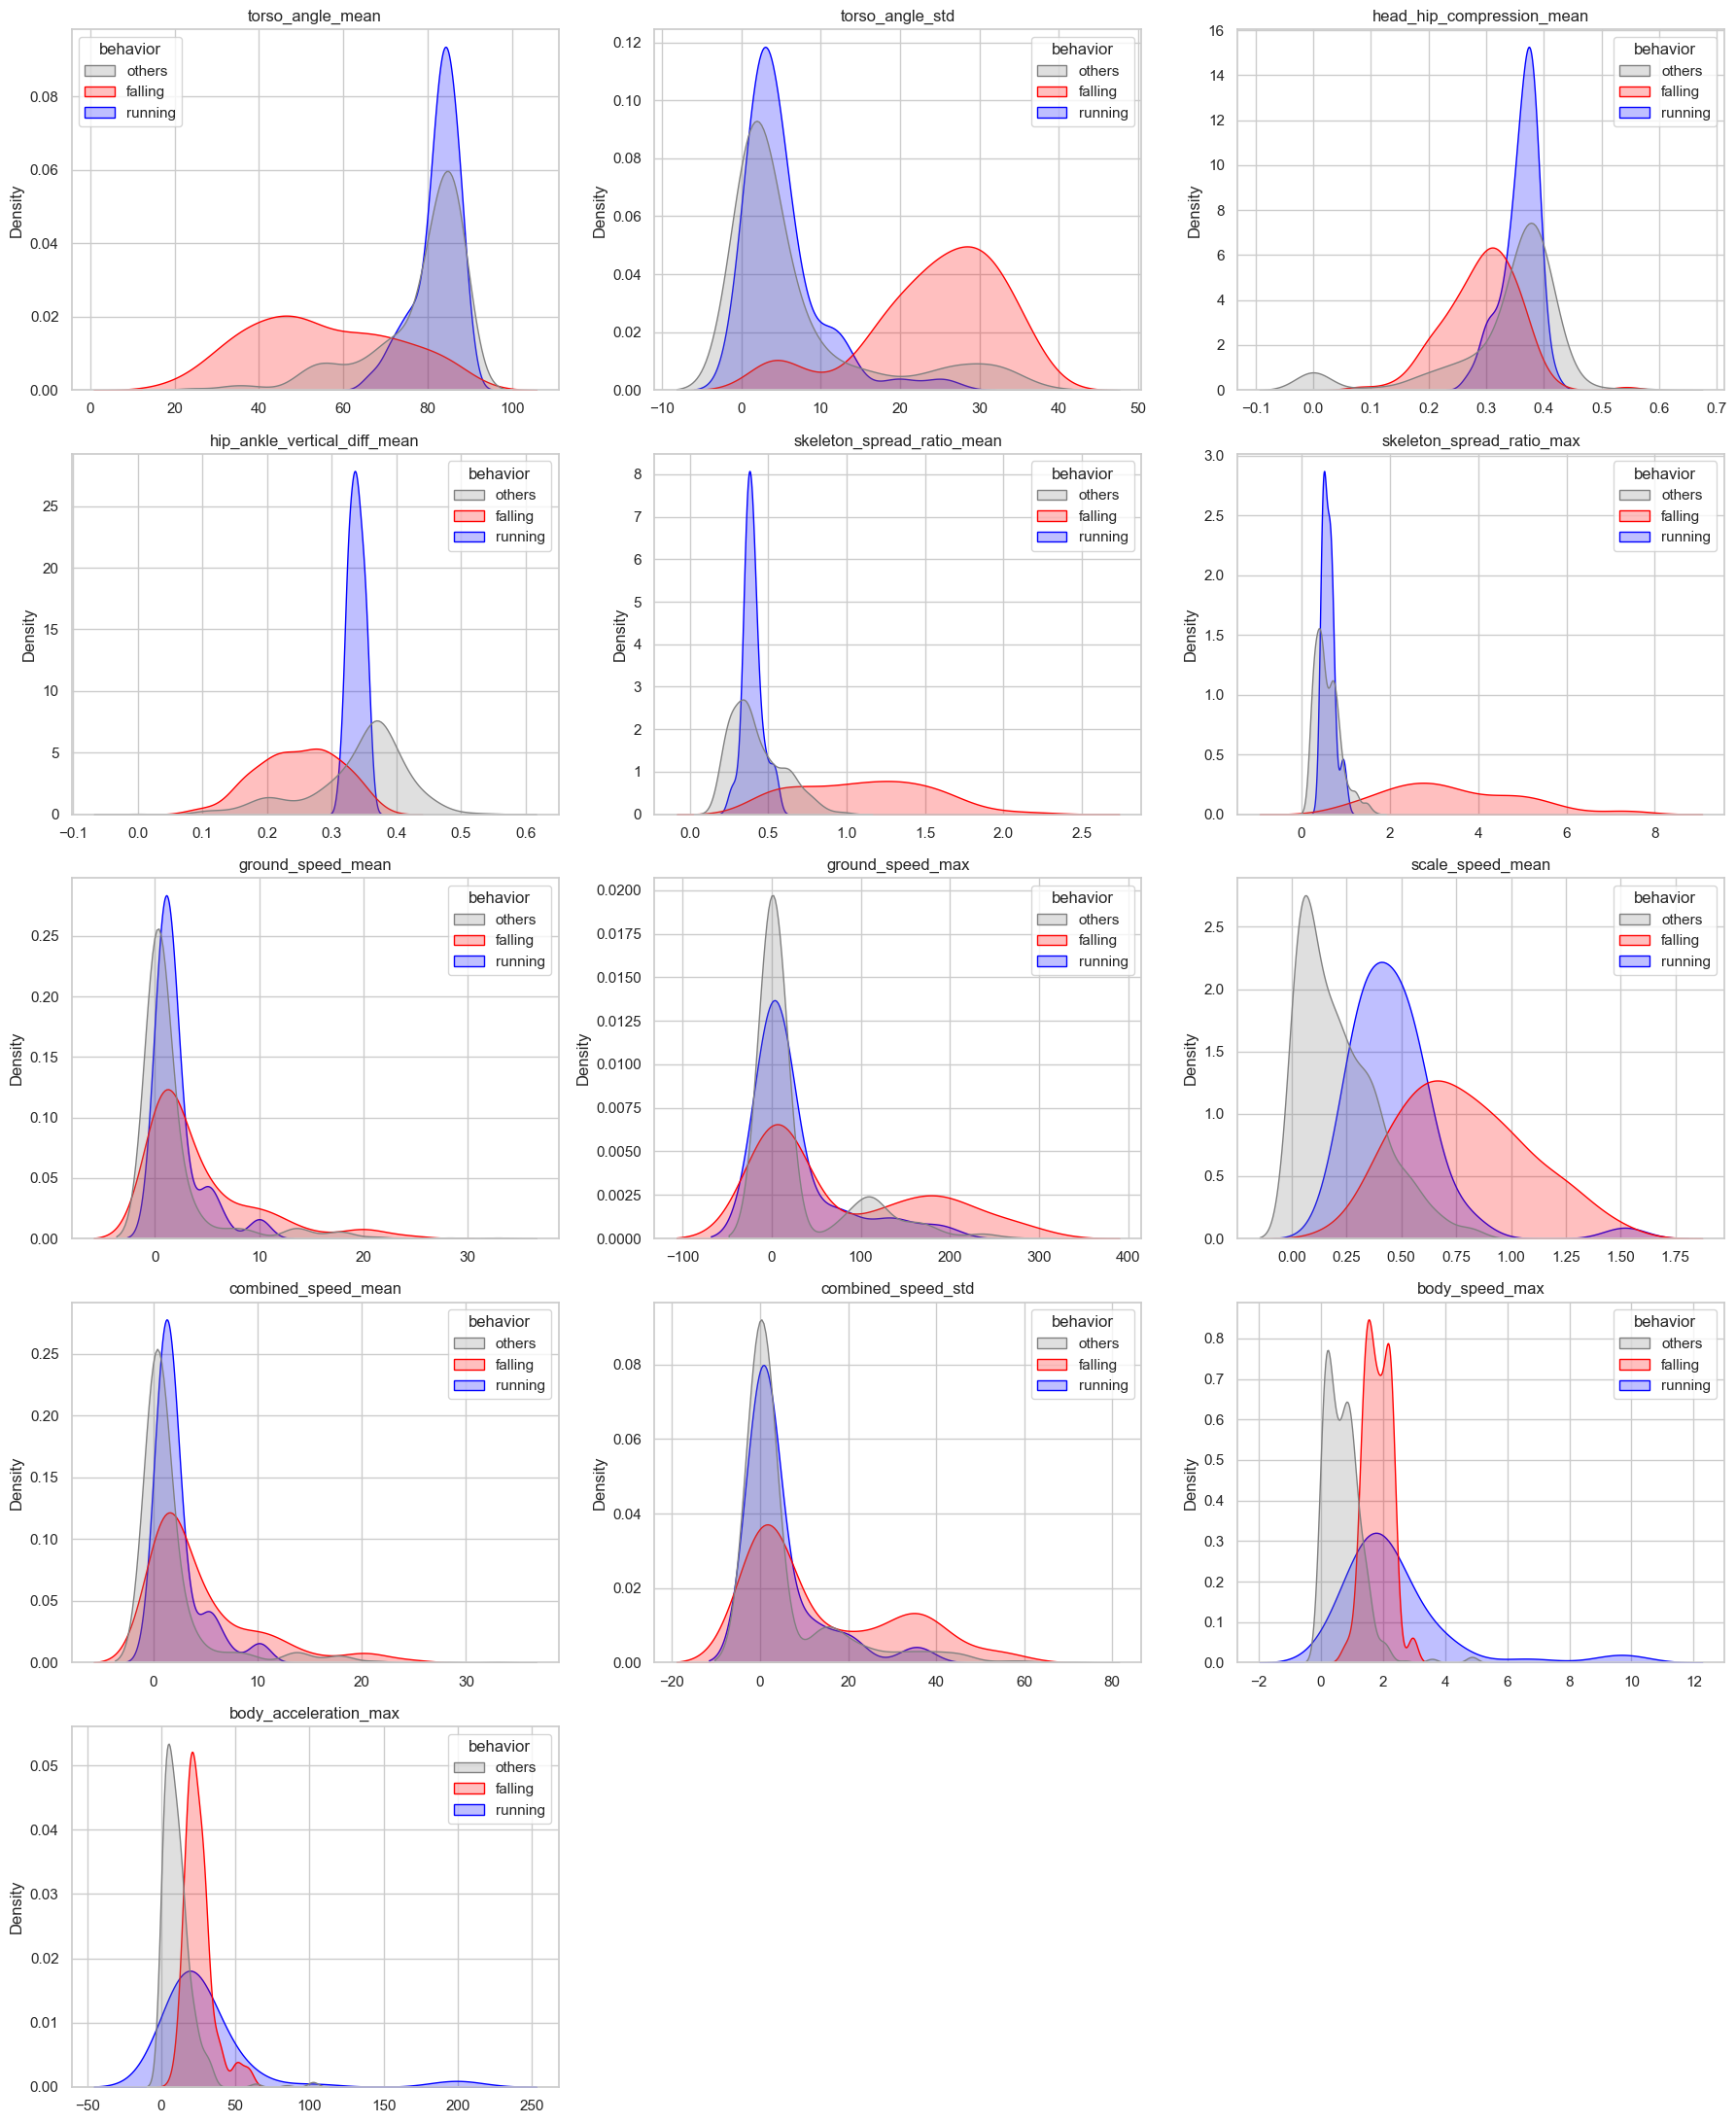

In [47]:
posture_metrics = [
    "torso_angle_mean", "torso_angle_std", "head_hip_compression_mean",
    "hip_ankle_vertical_diff_mean", "skeleton_spread_ratio_mean", "skeleton_spread_ratio_max",
    "ground_speed_mean", "ground_speed_max", "scale_speed_mean", "combined_speed_mean",
    "combined_speed_std", "body_speed_max", "body_acceleration_max"
]

print("Visualizing 13 Posture Geometry Features using Normalized KDE plots...")
fig, axes = plt.subplots(5, 3, figsize=(18, 22))
axes = axes.flatten()

for idx, feat in enumerate(posture_metrics):
    sns.kdeplot(data=df, x=feat, hue="behavior", fill=True, common_norm=False, ax=axes[idx], palette=colors, warn_singular=False)
    axes[idx].set_title(feat)
    axes[idx].set_xlabel("")

# Hide empty subplots
for i in range(len(posture_metrics), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

Visualizing 4 Final Window Features using Normalized KDE plots...


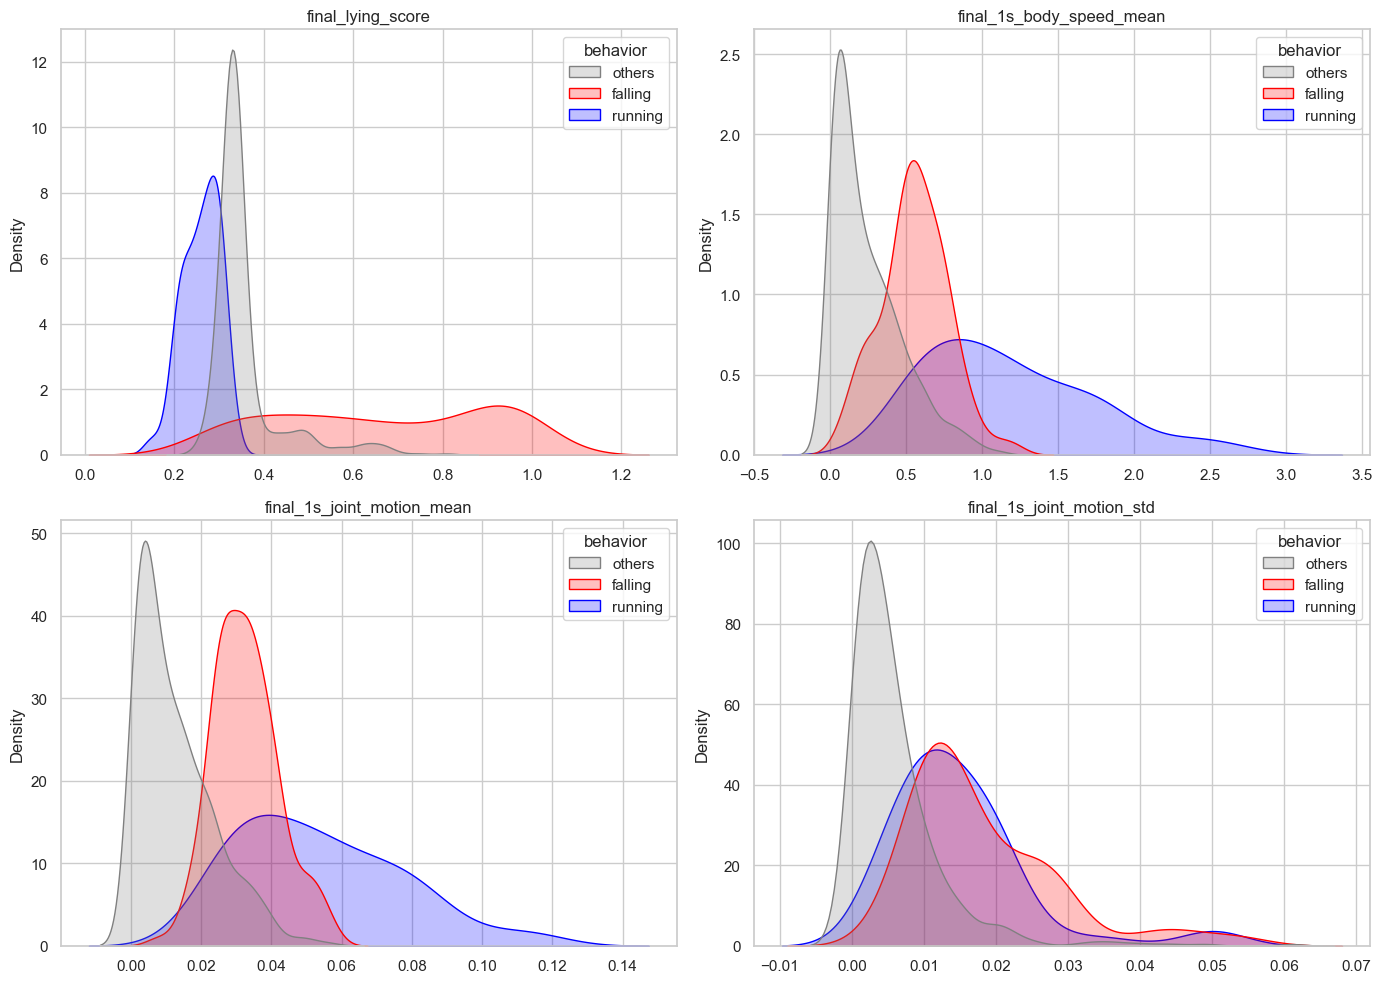

In [48]:
final_metrics = [
    "final_lying_score", "final_1s_body_speed_mean", 
    "final_1s_joint_motion_mean", "final_1s_joint_motion_std"
]

print("Visualizing 4 Final Window Features using Normalized KDE plots...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(final_metrics):
    sns.kdeplot(data=df, x=feat, hue="behavior", fill=True, common_norm=False, ax=axes[idx], palette=colors, warn_singular=False)
    axes[idx].set_title(feat)
    axes[idx].set_xlabel("")

plt.tight_layout()
plt.show()

Visualizing 4 Quality Control Features using Normalized KDE plots...


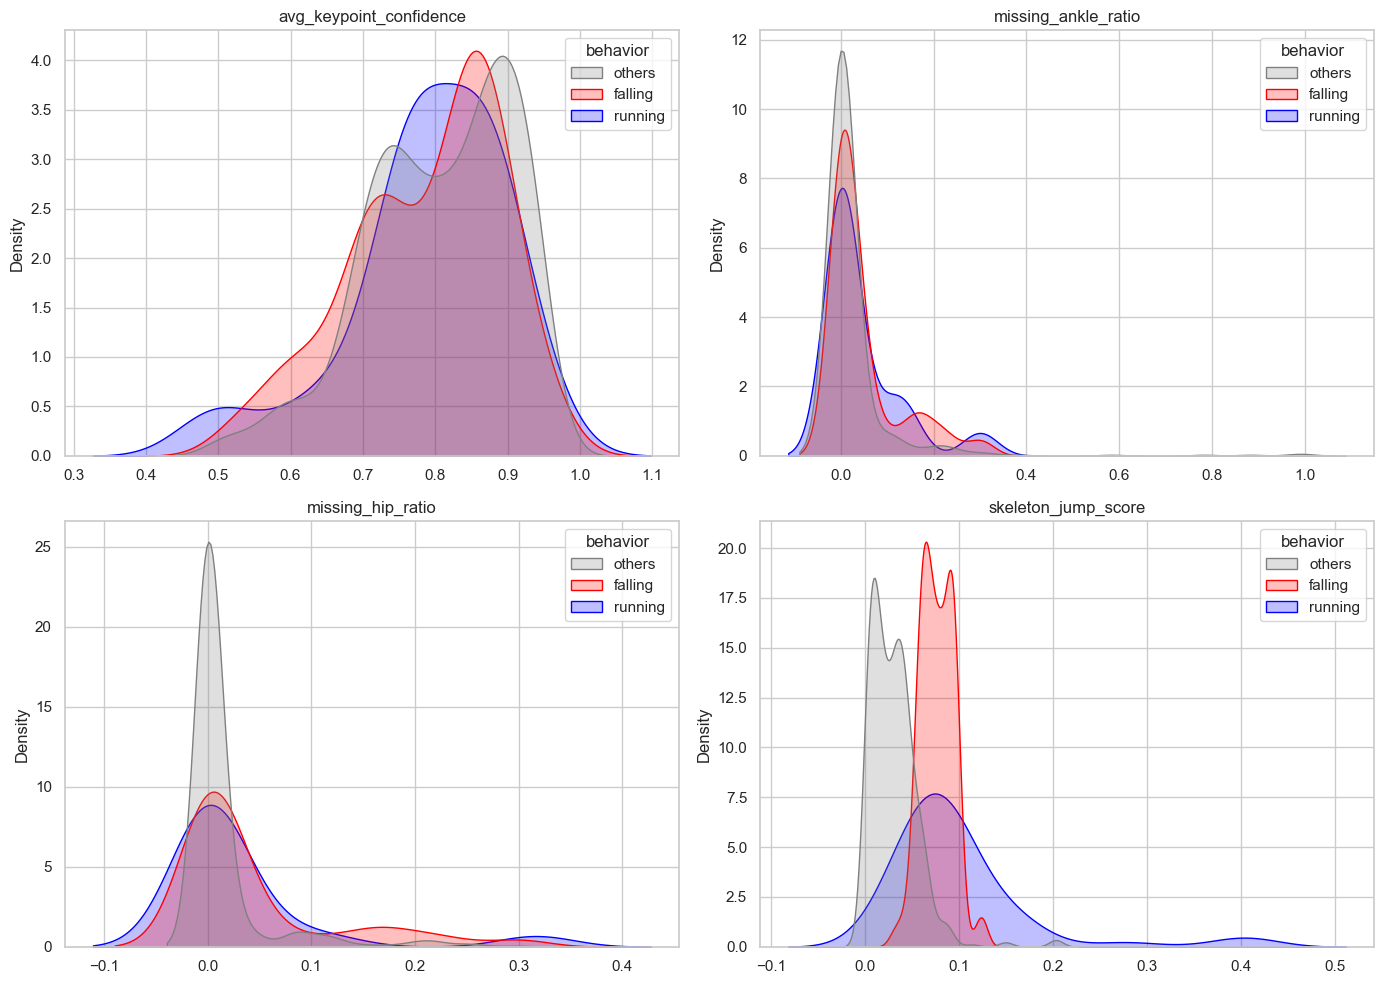

In [49]:
quality_metrics = [
    "avg_keypoint_confidence", "missing_ankle_ratio", 
    "missing_hip_ratio", "skeleton_jump_score"
]

print("Visualizing 4 Quality Control Features using Normalized KDE plots...")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, feat in enumerate(quality_metrics):
    sns.kdeplot(data=df, x=feat, hue="behavior", fill=True, common_norm=False, ax=axes[idx], palette=colors, warn_singular=False)
    axes[idx].set_title(feat)
    axes[idx].set_xlabel("")

plt.tight_layout()
plt.show()

## 5. EDA Task 2: Overlaid Time-Series Line Plots

For each of the 8 base metrics, we select a random sample of 25 windows per behavior class and plot their frame sequences ($t_0$ to $t_{14}$) as semi-transparent lines, overlaying the class average as a bold line. This visualizes temporal trends (red=falling, blue=running, grey=others).

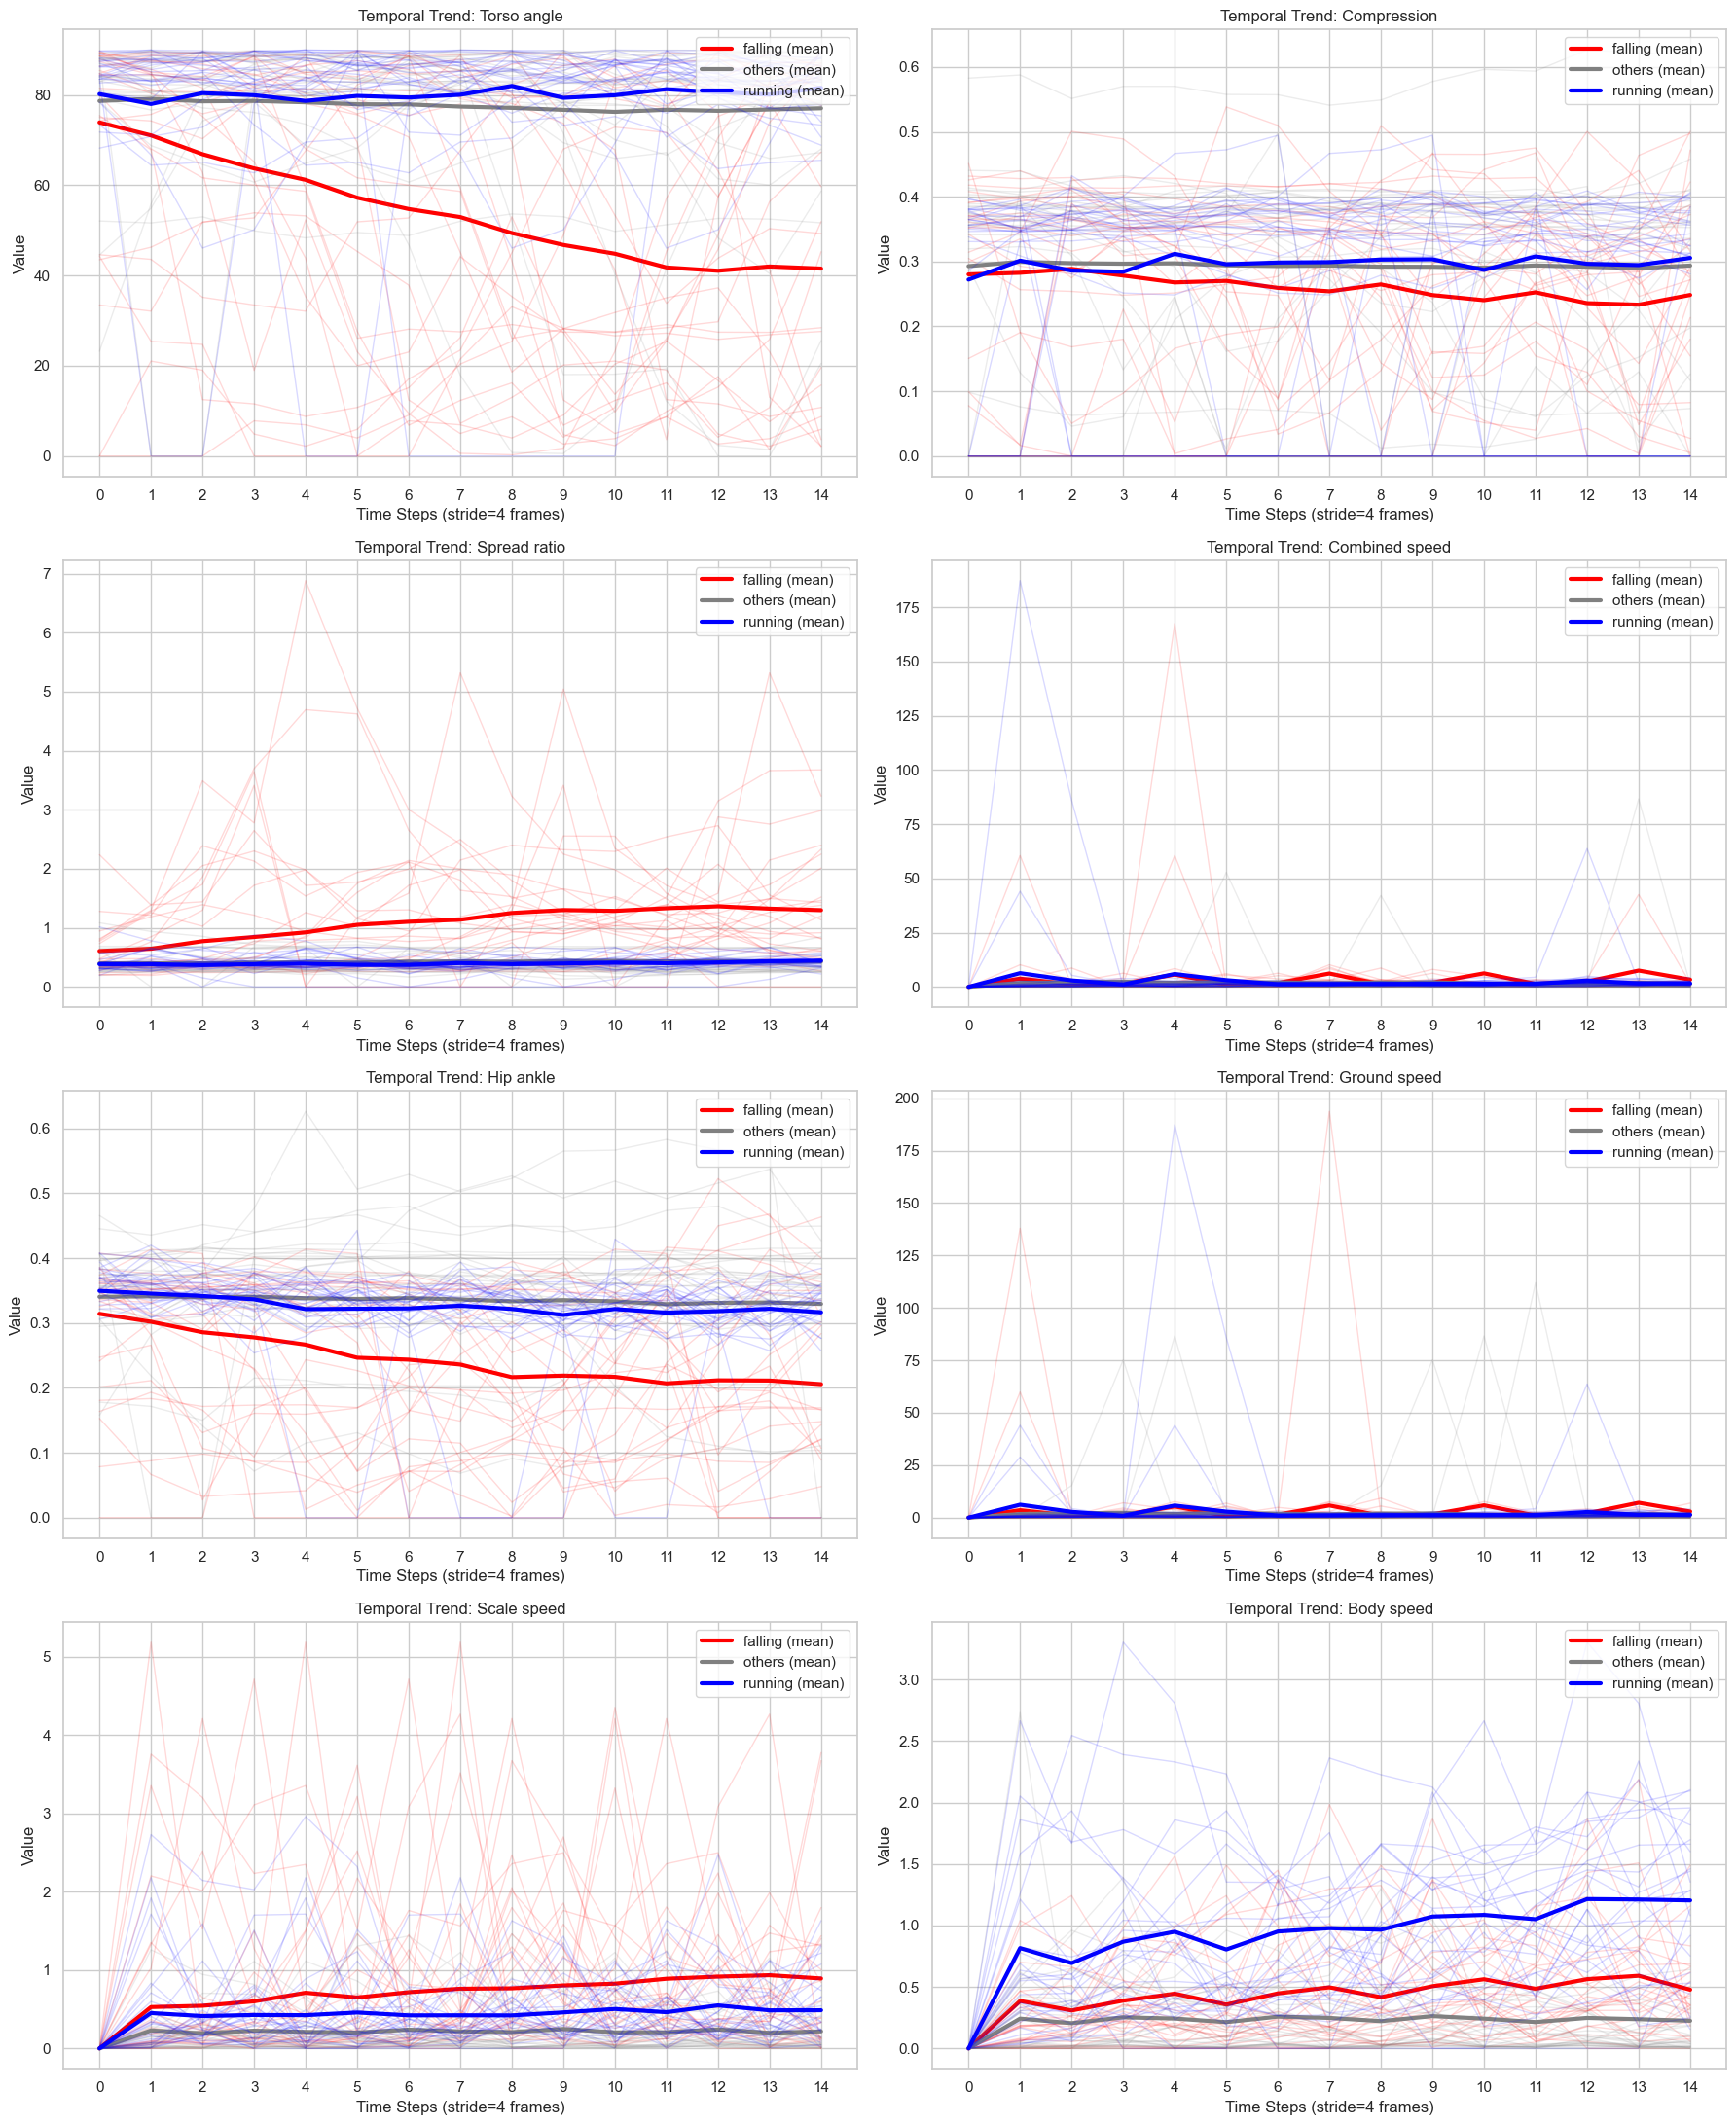

In [50]:
ts_metrics = [
    "torso_angle", "compression", "spread_ratio", "combined_speed", 
    "hip_ankle", "ground_speed", "scale_speed", "body_speed"
]

# Setup plot grid
fig, axes = plt.subplots(4, 2, figsize=(18, 22))
axes = axes.flatten()
time_steps = np.arange(15)  # 0 to 14 steps

np.random.seed(42)  # For reproducible sample selection

for m_idx, metric in enumerate(ts_metrics):
    # Gather feature names for this metric (step_metric_t0 to step_metric_t14)
    metric_cols = [f"step_{metric}_t{step}" for step in range(15)]
    ax = axes[m_idx]
    
    for behavior_name, group_df in df.groupby("behavior"):
        # Extract step sequences as numpy array
        sequences = group_df[metric_cols].values
        
        # Choose 25 random samples to plot as thin lines
        n_samples = min(25, len(sequences))
        sample_indices = np.random.choice(len(sequences), size=n_samples, replace=False)
        
        # Plot individual lines
        color = colors[behavior_name]
        for idx in sample_indices:
            ax.plot(time_steps, sequences[idx], color=color, alpha=0.15, linewidth=1)
            
        # Calculate and plot the bold mean line
        mean_seq = np.mean(sequences, axis=0)
        ax.plot(time_steps, mean_seq, color=color, label=f"{behavior_name} (mean)", linewidth=3)
        
    ax.set_title(f"Temporal Trend: {metric.replace('_', ' ').capitalize()}")
    ax.set_xlabel("Time Steps (stride=4 frames)")
    ax.set_ylabel("Value")
    ax.set_xticks(time_steps)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

## 6. Feature Transformations (Speed & Acceleration)

Locomotion speeds and accelerations are heavily right-skewed due to tracker bounding-box size variances and movement spikes. Applying a square root transformation compresses the long tails, making it easier to evaluate density curves and model fit.

Visualizing 5 Square Root Transformed Locomotion Features using Normalized KDE plots...


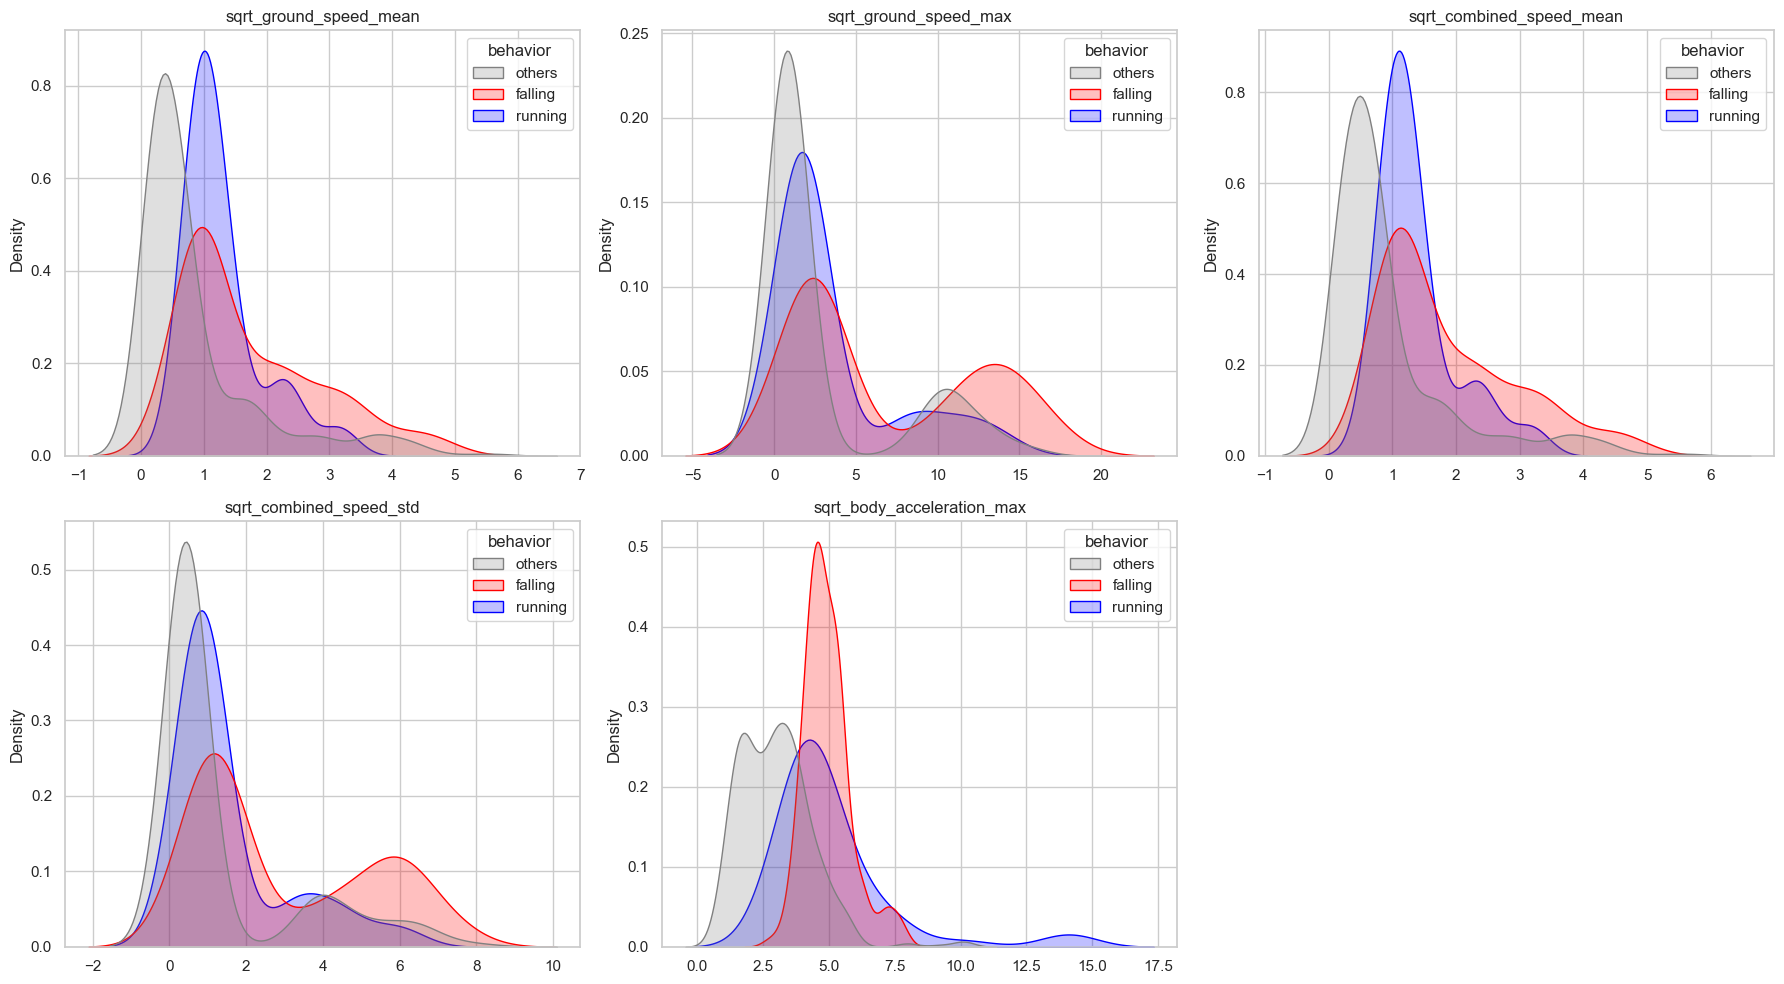

In [51]:
skewed_metrics = [
    "ground_speed_mean", "ground_speed_max", 
    "combined_speed_mean", "combined_speed_std", 
    "body_acceleration_max"
]

# Apply square root transformation
for metric in skewed_metrics:
    df[metric] = np.sqrt(df[metric])
    df.rename(columns={metric: f"sqrt_{metric}"}, inplace=True)

print("Visualizing 5 Square Root Transformed Locomotion Features using Normalized KDE plots...")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, metric in enumerate(skewed_metrics):
    feat = f"sqrt_{metric}"
    sns.kdeplot(data=df, x=feat, hue="behavior", fill=True, common_norm=False, ax=axes[idx], palette=colors, warn_singular=False)
    axes[idx].set_title(feat)
    axes[idx].set_xlabel("")

# Hide the last empty plots in the 2x3 grid
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

The mean and max values of `skeleton_spread_ratio` has a distribution that skews too much, thus require 2 times applying of log transformation.

Visualizing 2 Log Transformed Locomotion Features using Normalized KDE plots...


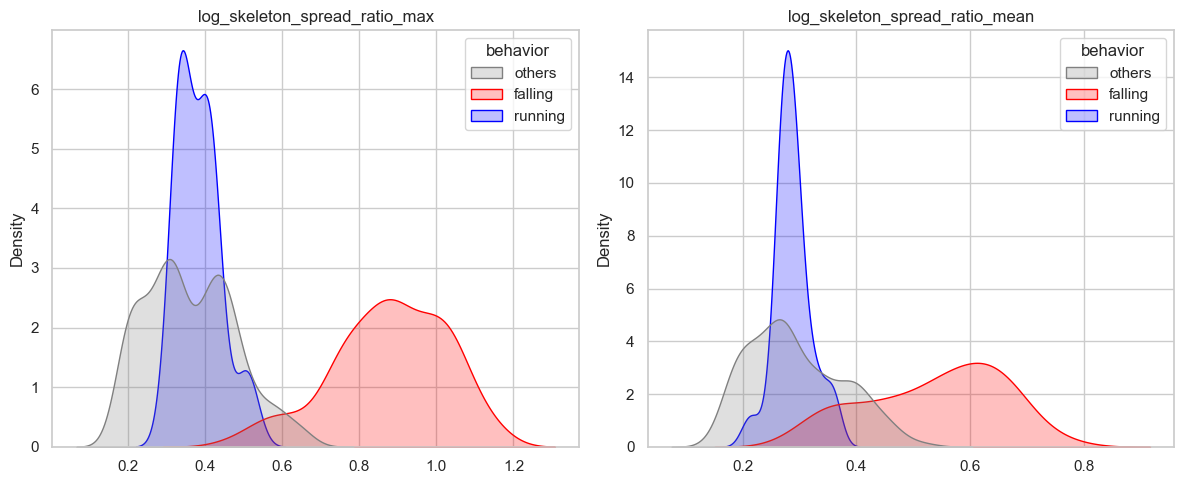

In [52]:
skewed_metrics = [
    "skeleton_spread_ratio_max", "skeleton_spread_ratio_mean"
]

# Apply natural logarithm transformation
for metric in skewed_metrics:
    df[metric] = np.log1p(np.log1p(df[metric]))
    df.rename(columns={metric: f"log_{metric}"}, inplace=True)

print("Visualizing 2 Log Transformed Locomotion Features using Normalized KDE plots...")
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes = axes.flatten()

for idx, metric in enumerate(skewed_metrics):
    feat = f"log_{metric}"
    sns.kdeplot(data=df, x=feat, hue="behavior", fill=True, common_norm=False, ax=axes[idx], palette=colors, warn_singular=False)
    axes[idx].set_title(feat)
    axes[idx].set_xlabel("")

plt.tight_layout()
plt.show()

## 7. Export Balanced Training Dataset

We save the resampled features matrix (`X_train_balanced`) and target labels (`y_train_balanced`) into a clean `.npz` file. This balanced dataset is ready to be imported directly for training classifier models (e.g. XGBoost, LightGBM, Random Forest).

In [53]:
# 1. Extract clean features and labels from the balanced df
# We drop metadata columns
drop_cols = ['video_id', 'behavior', 'label']
X_train_cleaned = df.drop(columns=drop_cols, errors='ignore').values
y_train_cleaned = df['label'].values

# 2. Save the balanced training split to a distinct file
cleaned_train_path = project_root / f'{dataset_name}_cleaned.npz'
np.savez_compressed(cleaned_train_path, X=X_train_cleaned, y=y_train_cleaned)

print(f"Successfully exported balanced training dataset to: {cleaned_train_path.absolute()}")

# 3. Verification load check
loaded = np.load(cleaned_train_path)
print(f"Verified loaded features matrix (X) shape: {loaded['X'].shape}")
print(f"Verified loaded labels array (y) shape     : {loaded['y'].shape}")

Successfully exported balanced training dataset to: D:\Bill\IT\RMIT\Capstone\supported_tools\AutoLabeling\test_cleaned.npz
Verified loaded features matrix (X) shape: (631, 141)
Verified loaded labels array (y) shape     : (631,)
